In [1]:
import numpy as np
import matplotlib.transforms
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

In [2]:
import mpl2typ

In [3]:
# run this cell to get the best match between the matplotlib and Typst figures
%matplotlib inline
%config InlineBackend.print_figure_kwargs = dict(bbox_inches=None)

In [4]:
mpl2typ_header = """\
#import "/mpl2typ/lib.typ": *
#import "/style.typ": *

#set page(width: auto, height: auto, margin: 0.9em)
"""

### A simple figure

Text(0.5, 1.0, 'my title')

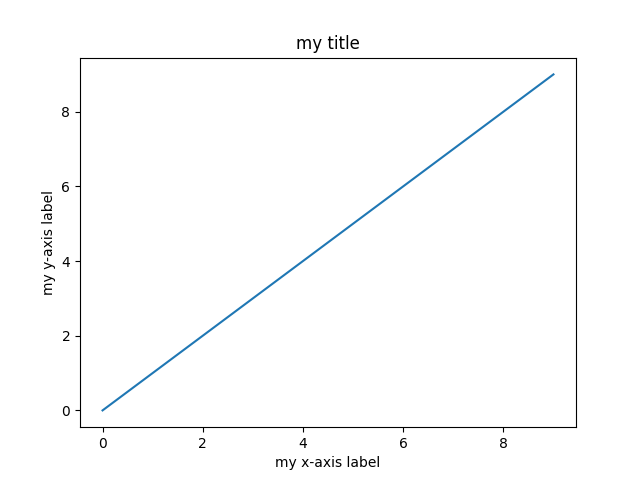

In [5]:
fig, ax = plt.subplots()
ax.plot(np.arange(10))
ax.set_xlabel("my x-axis label")
ax.set_ylabel("my y-axis label")
ax.set_title("my title")

In [ ]:
mpl2typ.Figure(fig).render("plot-simple/", header=mpl2typ_header)

### A figure with a legend

In [8]:
x0 = np.linspace(-5, 5, 11)
y0 = np.square(x0)
yerr0 = np.ones(x0.shape)

x1 = np.linspace(-3, 7, 11)
y1 = x1 * 3

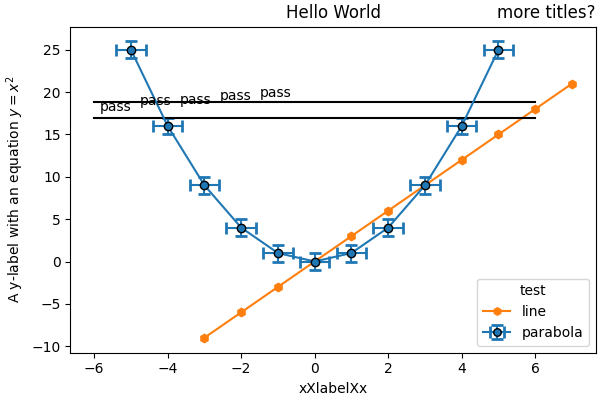

In [14]:
fig, ax = plt.subplots(figsize=(6, 4), layout="constrained")
yfactor = 1
ax.errorbar(x0, y0*yfactor, yerr=yerr0*yfactor, capsize=4, xerr=0.4, capthick=2, marker="o", mec="k", label="parabola")
ax.plot(x1, y1*yfactor, marker="h", label="line")
ax.set_title("Hello World")
ax.set_title("more titles?", loc="right")
ax.set_xlabel("xXlabelXx")
ax.set_ylabel("A y-label with an equation $y = x^2$")
ax.legend(ncols=1, markerscale=0.9, loc=4, title="test")
for i, va in enumerate(["top", "center_baseline", "center", "baseline", "bottom"]):
    ax.text(i * 40 + 100, 300, "pass", transform=matplotlib.transforms.IdentityTransform(), va=va)

ax.plot((-6, 6), [17] * 2, color="k")
ax.plot((-6, 6), [18.8] * 2, color="k")

In [10]:
mpl2typ.Figure(fig).render("plot-legend/", header=mpl2typ_header)

### A figure with complex errorbars
**ERROR**: The legend is not showing the correct markers in the Typst figure.

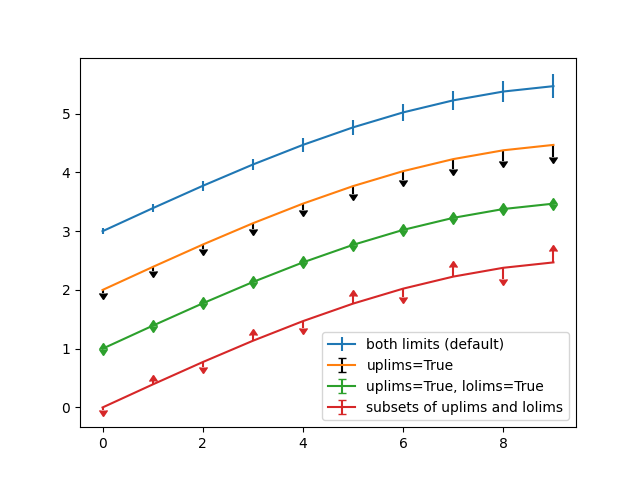

In [15]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots()
x = np.arange(10)
y = 2.5 * np.sin(x / 20 * np.pi)
yerr = np.linspace(0.05, 0.2, 10)

ax.errorbar(x, y + 3, yerr=yerr, label='both limits (default)')

ax.errorbar(x, y + 2, yerr=yerr, uplims=True, ecolor="k", label='uplims=True')

ax.errorbar(x, y + 1, yerr=yerr, uplims=True, lolims=True,
             label='uplims=True, lolims=True')

upperlimits = [True, False] * 5
lowerlimits = [False, True] * 5
ax.errorbar(x, y, yerr=yerr, uplims=upperlimits, lolims=lowerlimits,
             label='subsets of uplims and lolims')

ax.legend()

In [16]:
mpl2typ.Figure(fig).render("plot-error-limits/", header=mpl2typ_header)

### Title position and rotation

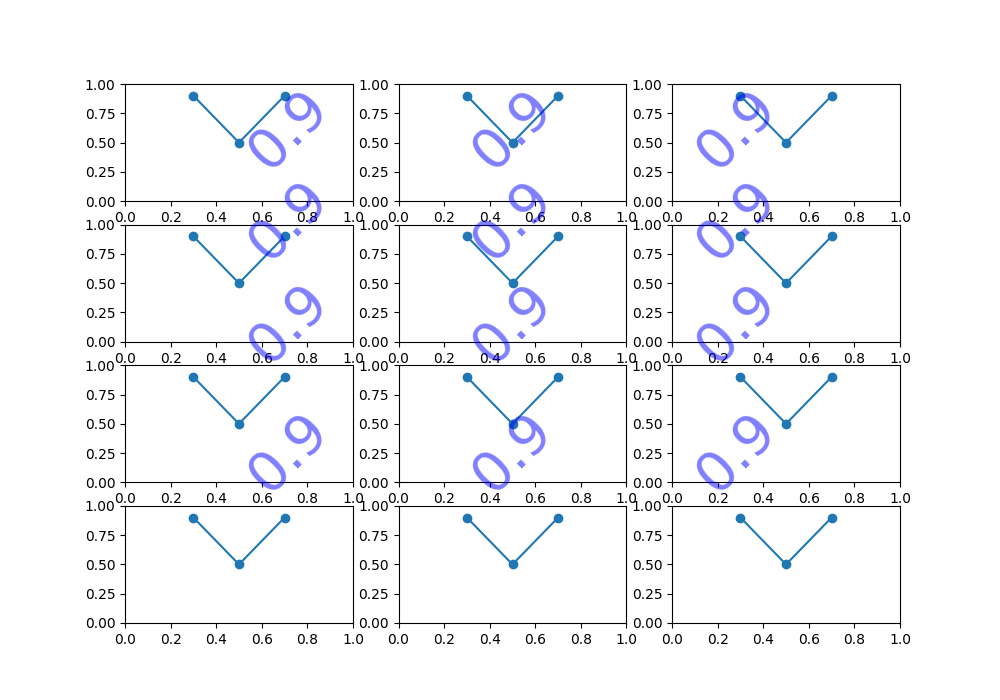

In [17]:
fig, axs = plt.subplots(ncols=3, nrows=4, figsize=(10, 7))

vertical = ["top", "center", "baseline", "bottom"]
horizontal = ["left", "center", "right"]
mode = "default"
kwargs = dict(y=1.0, pad=0, rotation=45, rotation_mode=mode, fontsize=40, color="blue", alpha=0.5)
x = (0.3, 0.5, 0.7)
y = (0.9, 0.5, 0.9)

title = r'$0.9$'
for i, va in enumerate(vertical):
    for j, ha in enumerate(horizontal):
        axs[i, j].set_title(title, **kwargs, va=va, ha=ha)
        axs[i, j].set_xlim(0, 1)
        axs[i, j].set_ylim(0, 1)
        axs[i, j].plot(x, y, marker="o")

In [18]:
mpl2typ.Figure(fig).render("plot-title/", header=mpl2typ_header)

### A figure with different ticks

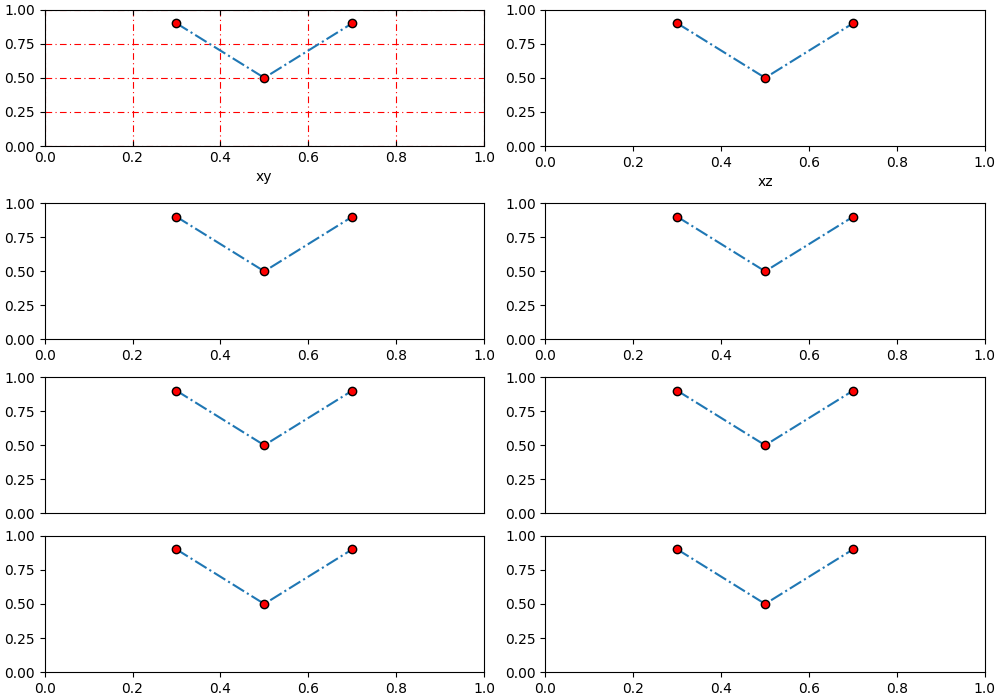

In [20]:
ncols = 2
nrows = 4
fig, axs = plt.subplots(ncols=ncols, nrows=nrows, figsize=(10, 7), layout="constrained")

x = (0.3, 0.5, 0.7)
y = (0.9, 0.5, 0.9)

for i in range(nrows):
    for j in range(ncols):
        axs[i, j].set_xlim(0, 1)
        axs[i, j].set_ylim(0, 1)
        axs[i, j].plot(x, y, marker="o", ls="-.", mec="k", mfc="red")#, alpha=0.5)

axs[0,0].set_xlabel("xy")
axs[0,1].set_xlabel("xz")

axs[2,0].tick_params(axis="x", labeltop=False, labelbottom=False, bottom=False)
axs[2,1].tick_params(axis="x", labeltop=False, labelbottom=False, bottom=False)

axs[0,0].grid(color="red", ls=(0, (6, 3, 1, 3)), which="major")
axs[0,0].tick_params(axis="x", bottom=True, top=True, direction="in")

In [21]:
mpl2typ.Figure(fig).render("plot-ticks/", header=mpl2typ_header)

### A figure with an inset

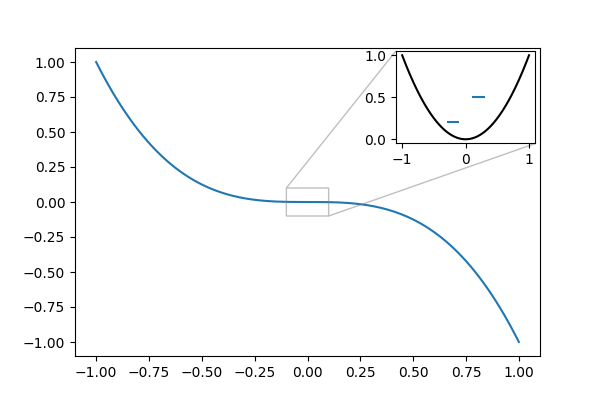

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))

x = np.linspace(-1, 1, 201)
ax.plot(x, -x**3)

inset_size = (0.3, 0.3)
ix = ax.inset_axes([0.69, 0.69, *inset_size])
ix.plot(x, x**2, color="k")
ix.hlines(0.2, -0.3, -0.1)
ix.hlines(0.5, 0.1, 0.3)
ax.indicate_inset(
    bounds=(-0.1, -0.1, 0.2, 0.2),
    inset_ax=ix,
)

In [ ]:
mpl2typ.Figure(fig).render("plot-inset/", header=mpl2typ_header)

### A figure with (horizontal and vertical) spans
**ERROR**: The spans are drawn in absolute coordinate instead of relative ones.

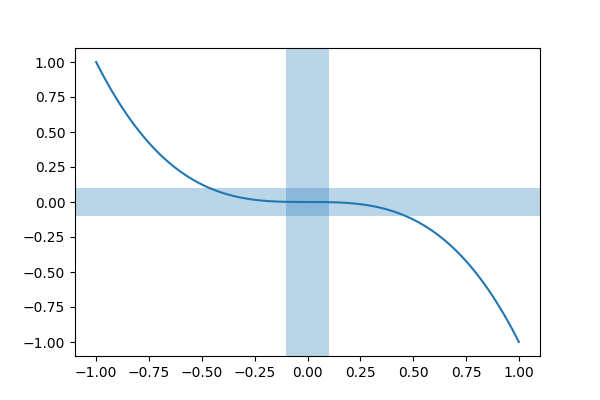

In [28]:
fig, ax = plt.subplots(figsize=(6, 4))

x = np.linspace(-1, 1, 201)
ax.plot(x, -x**3)
ax.axhspan(-0.1, 0.1, alpha=0.3)
ax.axvspan(-0.1, 0.1, alpha=0.3)

In [29]:
mpl2typ.Figure(fig).render("plot-span/", header=mpl2typ_header)

### A figure with a LineCollection

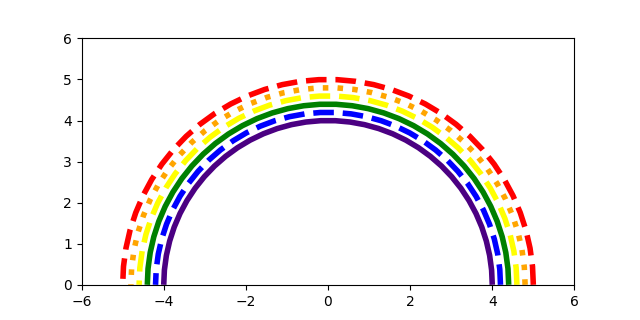

In [30]:
import matplotlib.pyplot as plt
import numpy as np

from matplotlib.collections import LineCollection

colors = ["indigo", "blue", "green", "yellow", "orange", "red"]
linestyle = ["solid", "dashed", "solid", "dashed", "dotted", "dashed"]

# create a list of half-circles with varying radii
theta = np.linspace(0, np.pi, 36)
radii = np.linspace(4, 5, num=len(colors))
arcs = [np.column_stack([r * np.cos(theta), r * np.sin(theta)]) for r in radii]

fig, ax = plt.subplots(figsize=(6.4, 3.2))
# set axes limits manually because Collections do not take part in autoscaling
ax.set_xlim(-6, 6)
ax.set_ylim(0, 6)
ax.set_aspect("equal")  # to make the arcs look circular

# create a LineCollection with the half-circles
# its properties can be set per line by passing a sequence (here used for *colors*)
# or they can be set for all lines by passing a scalar (here used for *linewidths*)
line_collection = LineCollection(arcs, colors=colors, linewidth=4, linestyle=linestyle)
ax.add_collection(line_collection)

In [31]:
mpl2typ.Figure(fig).render("plot-line-collection/", header=mpl2typ_header)

### A figure with some errorbars

In [32]:
n = 21
x = np.arange(n) - (n // 2)
y = np.random.rand(n) * 5
yerr = np.random.rand(n)

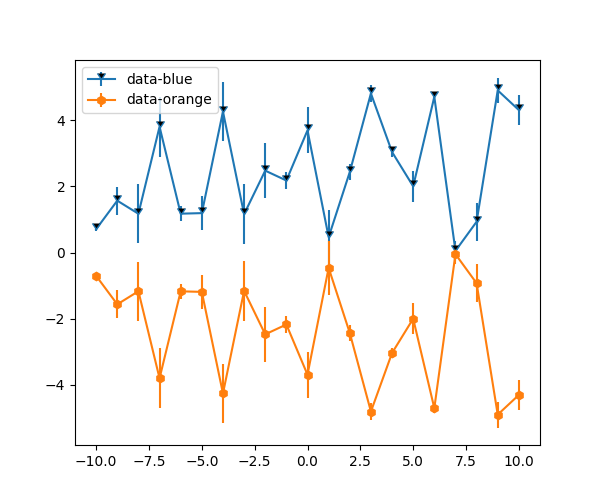

In [33]:
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(6, 5))
fig.set_dpi(100)
h0 = ax.errorbar(x, y, yerr=yerr, marker=7, mfc="k", label="data-blue")
h1 = ax.errorbar(x, -y, yerr=yerr, marker="h", label="data-orange")#, capsize=3)
ax.legend()

In [34]:
mpl2typ.Figure(fig).render("plot-errorbar/", header=mpl2typ_header)

### A figure with some scattered squares

In [49]:
n = 2
x = np.random.rand(n) * 2
y = np.random.rand(n) * 2
s = np.random.rand(n) * 1000 + 1

Text(0.5, 0, 'x')

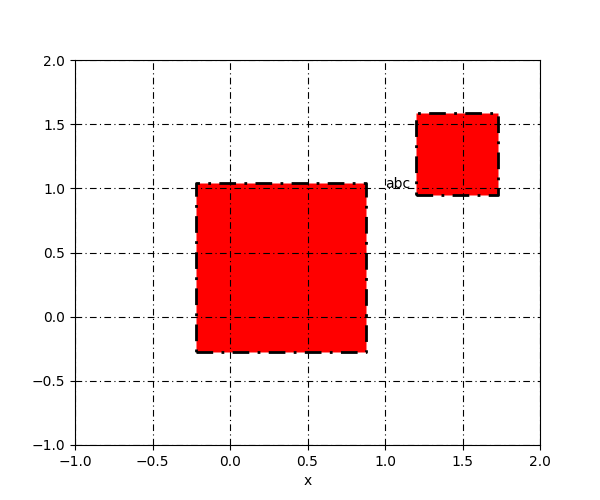

In [50]:
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(6, 5))

ax.scatter(x, y, s=16*s, facecolor="r", marker="s", edgecolor="k", lw=2, ls=(0, (6, 3, 1, 3)))
ax.set_xlim(-1, 2)
ax.set_ylim(-1, 2)
ax.grid(color="k", ls=(0, (6, 3, 1, 3)), which="major")
ax.text(1, 1, "abc", transform=ax.transData)
ax.set_xlabel("x")

In [51]:
mpl2typ.Figure(fig).render("plot-scatter/", header=mpl2typ_header)

### A figure with a colormesh

In [ ]:
y, x = np.mgrid[-20:21,-20:21]
z = np.arange(1681).reshape(41, 41)

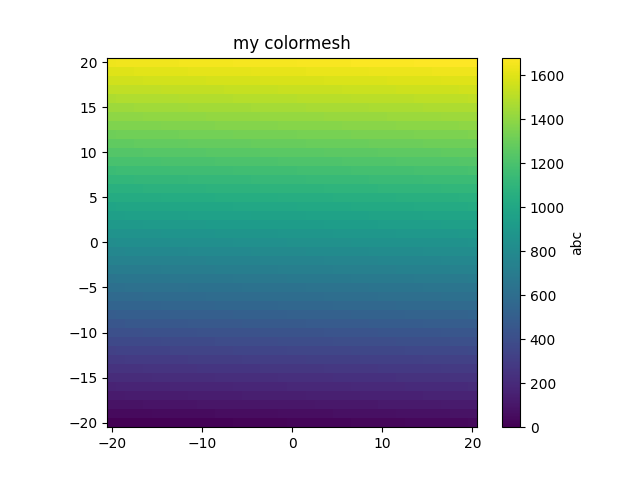

In [ ]:
fig, ax = plt.subplots()
cim = ax.pcolormesh(x, y, z, rasterized=False, vmax=1680)
fig.colorbar(cim, label="abc")
ax.set_title("my colormesh")
ax.set_box_aspect(1)

In [ ]:
mpl2typ.Figure(fig).render("plot-pcolormesh/", header=mpl2typ_header)

### A figure with some steps
**ERROR**: The grid lines are drawn on top of the step lines.

In [62]:
x = np.arange(14)
y = np.sin(x / 2)

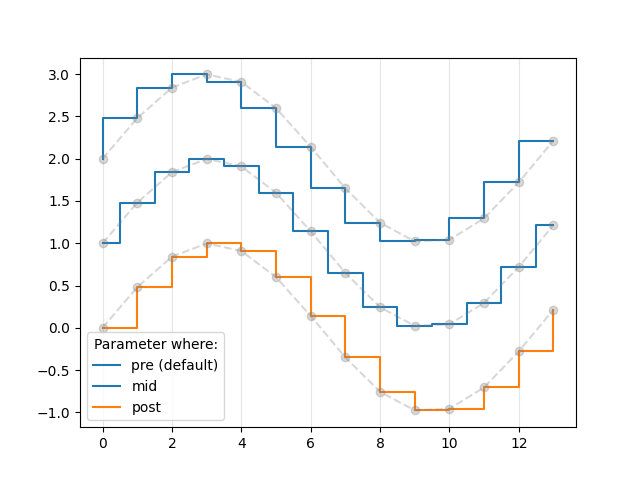

In [63]:
fig, ax = plt.subplots()

ax.step(x, y + 2, label='pre (default)')
ax.plot(x, y + 2, 'o--', color='grey', alpha=0.3)

ax.step(x, y + 1, where='mid', label='mid', color="tab:blue")
ax.plot(x, y + 1, 'o--', color='grey', alpha=0.3)

ax.step(x, y, where='post', label='post')
ax.plot(x, y, 'o--', color='grey', alpha=0.3)

ax.grid(axis='x', color='0.9')
ax.legend(title='Parameter where:')

In [64]:
mpl2typ.Figure(fig).render("plot-step/", header=mpl2typ_header)

### A figure with some stems

In [67]:
x = np.linspace(0.1, 2 * np.pi, 41)
y = np.exp(np.sin(x))

<StemContainer object of 3 artists>

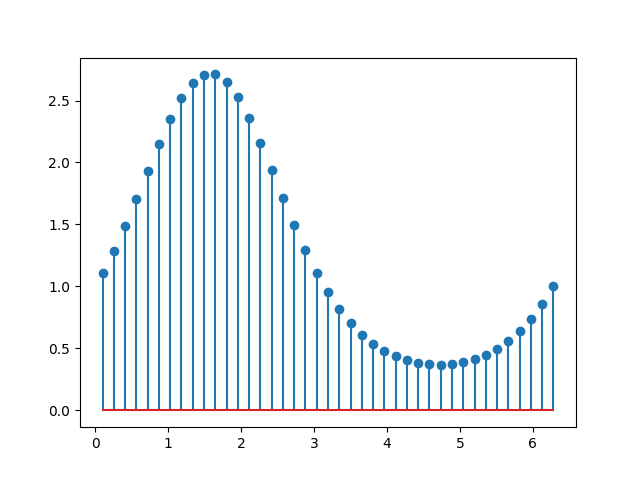

In [68]:
fig, ax = plt.subplots()

ax.stem(x, y)

In [69]:
mpl2typ.Figure(fig).render("plot-stem/", header=mpl2typ_header)

### A figure with some filled areas

In [70]:
x = np.arange(0.0, 2, 0.01)
y1 = np.sin(2 * np.pi * x)
y2 = 0.8 * np.sin(4 * np.pi * x)

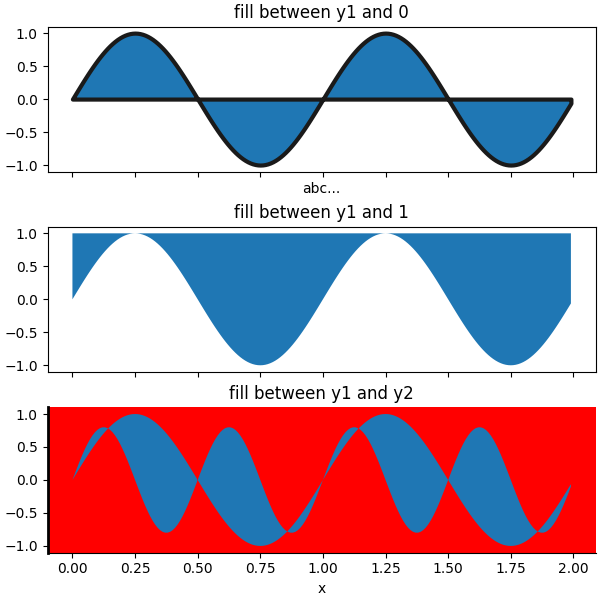

In [73]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True, figsize=(6, 6), layout="constrained")

ax1.fill_between(x, y1, ec="0.1", lw=3, label="some data...")
ax1.set_title('fill between y1 and 0')
ax1.set_xlabel('abc...')

ax2.fill_between(x, y1, 1)
ax2.set_title('fill between y1 and 1')

ax3.fill_between(x, y1, y2)
ax3.set_title('fill between y1 and y2')
ax3.set_xlabel('x')
ax3.set_facecolor("red")

ax3.spines.top.set_visible(False)
ax3.spines.right.set_visible(False)
ax3.spines.left.set_linewidth(2)

In [74]:
mpl2typ.Figure(fig).render("plot-fill-between/", header=mpl2typ_header)

### A figure with a path collection

In [ ]:
path1 = mpl.path.Path(
    vertices=[
        [-0.5, -0.5],
        [0.5, -0.5],
        [0.5, 0.5],
        [-0.5, 0.5],
        [-0.5, -0.5],
    ],
    closed=True
)

path2 = mpl.path.Path(
    vertices=[
        [-0.5, -0.5],
        [0.5, -0.5],
        [-0.5, 0.5],
        [-0.5, -0.5],
    ],
    closed=True
)

path3 = mpl.path.Path(
    vertices=[
        [-0.5, -0.5],
        [0.5, -0.9],
        [-0.5, 0.5],
        [-0.5, -0.5],
    ],
    closed=True
)

(-3.0, 3.0)

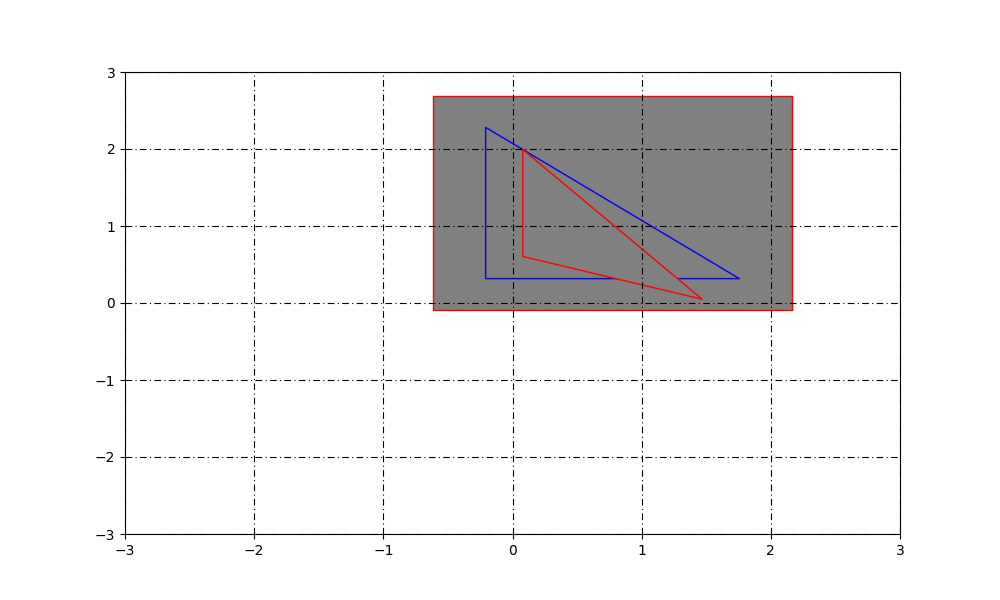

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
# fig.set_dpi(72)
ax.grid(color="k", ls=(0, (6, 3, 1, 3)), which="major")
col = mpl.collections.PathCollection([path1, path2, path3], sizes=[4, 2, 1], offsets=([100, 100]), linewidth=1, facecolor="0.5", edgecolor=["red", "blue"])#, offsets=xyo * 10)#, offset_transform=ax.transData)#, linewidths=[1, 5], edgecolors=["red", "blue", "green"])
ax.add_collection(col)
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)

In [ ]:
mpl2typ.Figure(fig).render("plot-path-collection/", header=mpl2typ_header)

### A figure with a standalone axes

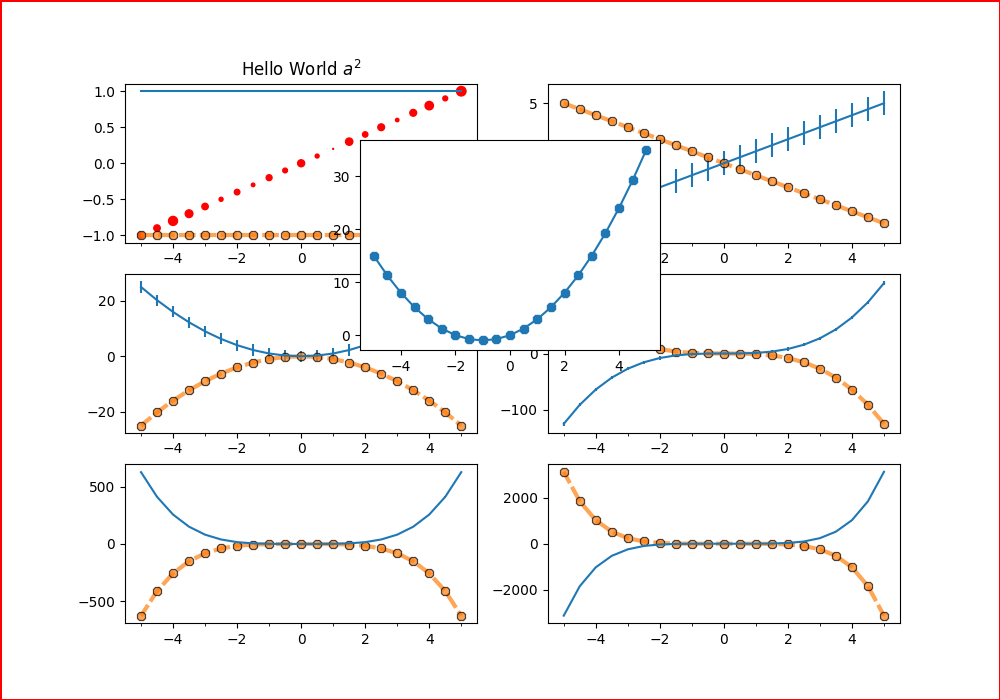

In [ ]:
fig, axs = plt.subplots(ncols=2, nrows=3, figsize=(10, 7))
fig.set_edgecolor("r")
fig.set_linewidth(2)

x = np.linspace(-5, 5, num=21)
kwargs = dict(marker="o", mec="k")
ax = fig.add_axes((0.36, 0.5, 0.3, 0.3))
ax.plot(x, 2*x + x**2, marker="8")
axs[0,0].set_title("Hello World $a^2$")

for i, ax in enumerate(axs.flatten()):
    ax.errorbar(x, x**i, yerr=np.ones(x.shape) * i)
    ax.plot(x, -x**i, linewidth=3, ls=(0.9, (4, 1)), alpha=0.7, mec="k", mew=0.9, marker="8")
    ax.xaxis.set_minor_locator(mpl.ticker.AutoMinorLocator(2))

axs[0,0].scatter(x, x/5, s=np.random.rand(len(x))*50 + 0.1, color="r")

In [ ]:
mpl2typ.Figure(fig).render("plot-standalone/", header=mpl2typ_header)

### A figure with a gridspec

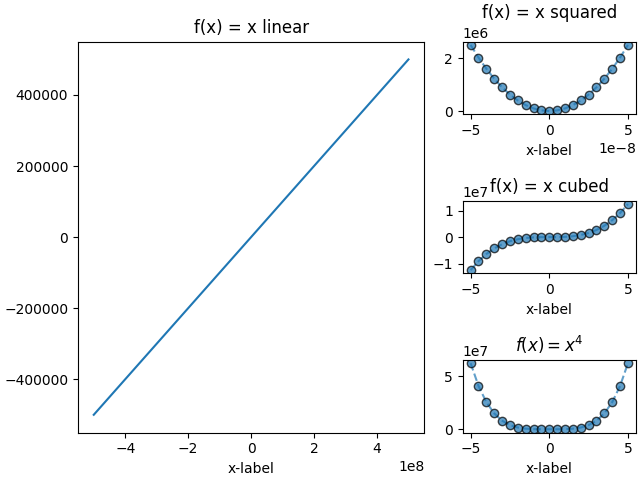

In [ ]:
fig = plt.figure(layout="constrained")
gs = mpl.gridspec.GridSpec(3, 2, figure=fig, width_ratios=(2, 1))

x = np.linspace(-5, 5, num=21)
kwargs = dict(marker="o", mec="k", ls="dashed", alpha=0.7)

ax0 = fig.add_subplot(gs[:, 0])
ax0.plot(x * 1e8, x**1 * 1e5)
ax0.set_title("f(x) = x linear")

ax = fig.add_subplot(gs[0, 1])
ax.plot(x * 1e-8, x**2 * 1e5, **kwargs)
ax.set_title("f(x) = x squared")

ax = fig.add_subplot(gs[1, 1])
ax.plot(x, x**3 * 1e5, **kwargs)
ax.set_title("$f(x) = x^3$")
ax.set_title("f(x) = x cubed")

ax = fig.add_subplot(gs[2, 1])
ax.plot(x, x**4 * 1e5, **kwargs)
ax.set_title("$f(x) = x^4$")

for ax in fig.get_axes():
    ax.set_xlabel("x-label")

In [12]:
mpl2typ.Figure(fig).render("plot-gridspec/", header=mpl2typ_header)

### A figure with multiple gridspecs

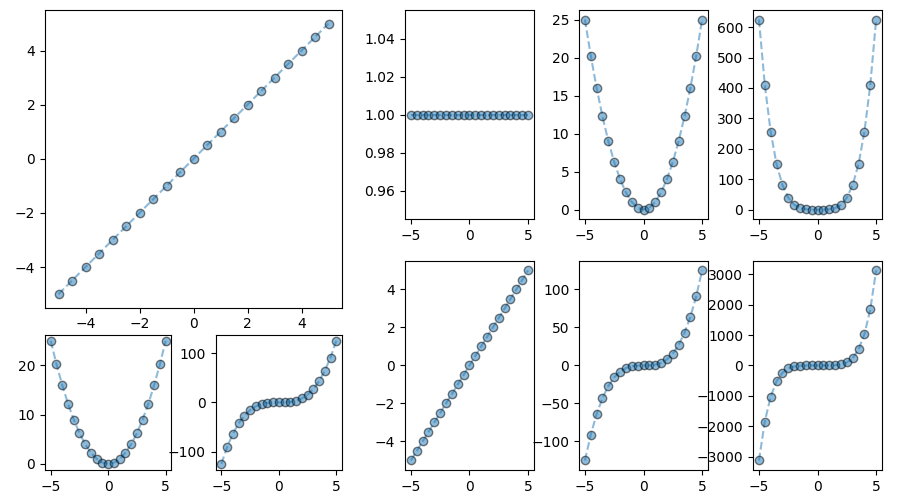

In [ ]:
fig = plt.figure(figsize=(9, 5))

x = np.linspace(-5, 5, num=21)
kwargs = dict(marker="o", mec="k", ls="dashed")

gs1 = mpl.gridspec.GridSpec(3, 2, figure=fig)
gs1.update(left=0.05, right=0.38, top=0.98, bottom=0.06, wspace=0.35)
ax1 = fig.add_subplot(gs1[:2, :2])
ax1.plot(x, x**1, **kwargs, alpha=0.5)

ax2 = fig.add_subplot(gs1[2, 0])
ax2.plot(x, x**2, **kwargs, alpha=0.5)

ax3 = fig.add_subplot(gs1[2, 1])
ax3.plot(x, x**3, **kwargs, alpha=0.5)


gs2 = mpl.gridspec.GridSpec(2, 3, figure=fig)
gs2.update(left=0.45, right=0.98, top=0.98, bottom=0.06, wspace=0.35)
for i in range(6):
    ax = fig.add_subplot(gs2[i%2, i//2])
    ax.plot(x, x**i, **kwargs, alpha=0.5)

In [31]:
mpl2typ.Figure(fig).render("plot-multiple-gridspecs/", header=mpl2typ_header)